# Variational Autoencoder (VAE) for CIFAR-10 Image Generation

This notebook implements a complete VAE pipeline including:
1. **Encoder-Decoder Architecture** with reparameterization trick
2. **Training on CIFAR-10** dataset
3. **Latent Space Interpolation** for image morphing
4. **β-VAE Modification** for disentangled representations

---

## 1. Setup and Imports

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


## 2. Load CIFAR-10 Dataset

In [ ]:
# Data transformations - normalize to [0, 1] range
transform = transforms.Compose([
    transforms.ToTensor(),
])

# Download and load CIFAR-10
train_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

# Data loaders
BATCH_SIZE = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# CIFAR-10 class names
CLASSES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck']

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Image shape: {train_dataset[0][0].shape}")

100%|██████████| 170M/170M [00:03<00:00, 44.1MB/s]


Training samples: 50000
Test samples: 10000
Image shape: torch.Size([3, 32, 32])


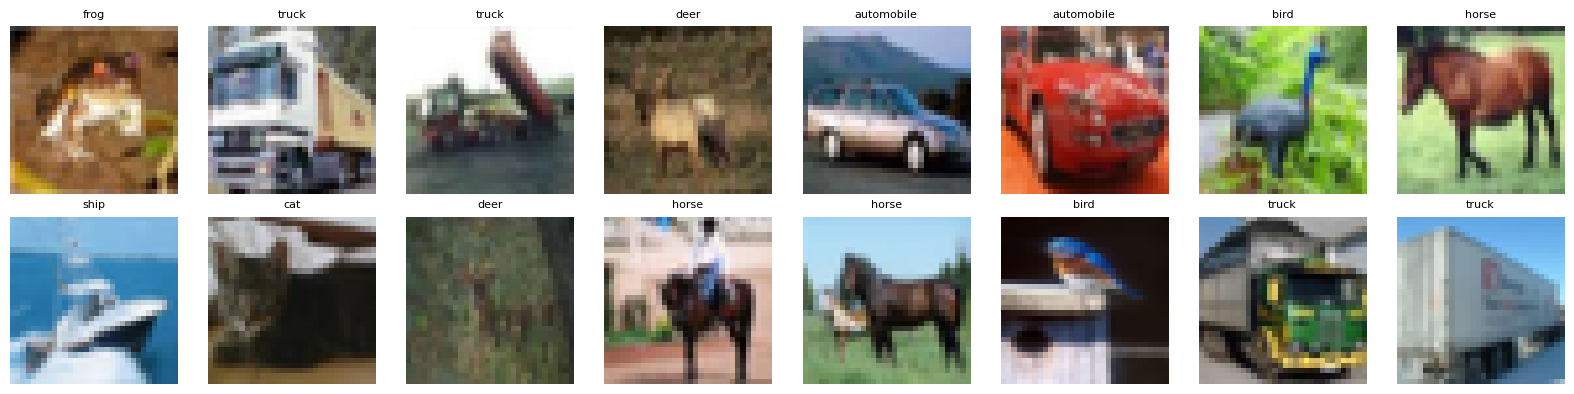

Sample CIFAR-10 training images


In [ ]:
# Visualize some training images
def show_images(images, titles=None, rows=2, cols=8, figsize=(16, 4)):
    """Display a grid of images."""
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = axes.flatten()

    for idx, (ax, img) in enumerate(zip(axes, images)):
        if torch.is_tensor(img):
            img = img.permute(1, 2, 0).numpy()
        img = np.clip(img, 0, 1)
        ax.imshow(img)
        ax.axis('off')
        if titles is not None and idx < len(titles):
            ax.set_title(titles[idx], fontsize=8)

    plt.tight_layout()
    plt.show()

# Show sample images
sample_images = [train_dataset[i][0] for i in range(16)]
sample_labels = [CLASSES[train_dataset[i][1]] for i in range(16)]
show_images(sample_images, sample_labels)
print("Sample CIFAR-10 training images")

---
## 3. Task 1: VAE Architecture Design

### 3.1 The Encoder
The encoder compresses a 32×32×3 RGB image into two vectors:
- **μ (mean)**: The center of the latent distribution
- **log σ² (log variance)**: The spread of the latent distribution

### 3.2 The Decoder  
The decoder reconstructs the image from a sampled latent vector.

### 3.3 The Reparameterization Trick
To enable backpropagation through sampling:
$$z = \mu + \sigma \cdot \epsilon, \quad \text{where } \epsilon \sim \mathcal{N}(0, I)$$

In [ ]:
class Encoder(nn.Module):
    """
    Encoder network that compresses 32x32x3 images to latent distributions.

    Architecture:
    - 4 convolutional layers with batch normalization
    - Progressively increases channels: 3 -> 32 -> 64 -> 128 -> 256
    - Outputs mean and log-variance for the latent space
    """

    def __init__(self, latent_dim=128):
        super(Encoder, self).__init__()
        self.latent_dim = latent_dim

        # Convolutional layers
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1)   # 32x32 -> 16x16
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1)  # 16x16 -> 8x8
        self.bn2 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1) # 8x8 -> 4x4
        self.bn3 = nn.BatchNorm2d(128)

        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1) # 4x4 -> 2x2
        self.bn4 = nn.BatchNorm2d(256)

        # Flatten size: 256 * 2 * 2 = 1024
        self.flatten_size = 256 * 2 * 2

        # Fully connected layers for mean and log-variance
        self.fc_mu = nn.Linear(self.flatten_size, latent_dim)
        self.fc_logvar = nn.Linear(self.flatten_size, latent_dim)

    def forward(self, x):
        """Forward pass returning mean and log-variance."""
        # Convolutional encoding
        x = F.leaky_relu(self.bn1(self.conv1(x)), 0.2)
        x = F.leaky_relu(self.bn2(self.conv2(x)), 0.2)
        x = F.leaky_relu(self.bn3(self.conv3(x)), 0.2)
        x = F.leaky_relu(self.bn4(self.conv4(x)), 0.2)

        # Flatten
        x = x.view(x.size(0), -1)

        # Get distribution parameters
        mu = self.fc_mu(x)
        logvar = self.fc_logvar(x)

        return mu, logvar

In [ ]:
class Decoder(nn.Module):
    """
    Decoder network that reconstructs 32x32x3 images from latent vectors.

    Architecture:
    - Fully connected layer to reshape latent vector
    - 4 transposed convolutional layers with batch normalization
    - Progressively decreases channels: 256 -> 128 -> 64 -> 32 -> 3
    """

    def __init__(self, latent_dim=128):
        super(Decoder, self).__init__()
        self.latent_dim = latent_dim

        # Initial projection
        self.fc = nn.Linear(latent_dim, 256 * 2 * 2)

        # Transposed convolutional layers (deconvolution)
        self.deconv1 = nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1)  # 2x2 -> 4x4
        self.bn1 = nn.BatchNorm2d(128)

        self.deconv2 = nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1)   # 4x4 -> 8x8
        self.bn2 = nn.BatchNorm2d(64)

        self.deconv3 = nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1)    # 8x8 -> 16x16
        self.bn3 = nn.BatchNorm2d(32)

        self.deconv4 = nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1)     # 16x16 -> 32x32

    def forward(self, z):
        """Forward pass reconstructing image from latent vector."""
        # Project and reshape
        x = self.fc(z)
        x = x.view(x.size(0), 256, 2, 2)

        # Transposed convolutions (upsampling)
        x = F.leaky_relu(self.bn1(self.deconv1(x)), 0.2)
        x = F.leaky_relu(self.bn2(self.deconv2(x)), 0.2)
        x = F.leaky_relu(self.bn3(self.deconv3(x)), 0.2)

        # Final layer with sigmoid to output [0, 1] range
        x = torch.sigmoid(self.deconv4(x))

        return x

In [ ]:
class VAE(nn.Module):
    """
    Variational Autoencoder combining Encoder and Decoder.

    Implements the reparameterization trick for differentiable sampling:
    z = μ + σ * ε, where ε ~ N(0, I)

    Parameters:
    - latent_dim: Dimension of the latent space
    - beta: Weight for KL divergence term (β-VAE)
    """

    def __init__(self, latent_dim=128, beta=1.0):
        super(VAE, self).__init__()
        self.latent_dim = latent_dim
        self.beta = beta

        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def reparameterize(self, mu, logvar):
        """
        Reparameterization trick: sample z from q(z|x).

        The trick allows gradients to flow through the sampling operation:
        z = μ + σ * ε, where ε ~ N(0, I)

        This is differentiable w.r.t. μ and σ, but not w.r.t. ε.
        """
        # Standard deviation from log variance
        std = torch.exp(0.5 * logvar)

        # Sample epsilon from standard normal
        eps = torch.randn_like(std)

        # Reparameterized sample
        z = mu + eps * std

        return z

    def forward(self, x):
        """Full forward pass: encode -> sample -> decode."""
        # Encode to distribution parameters
        mu, logvar = self.encoder(x)

        # Sample latent vector
        z = self.reparameterize(mu, logvar)

        # Decode to reconstruction
        x_recon = self.decoder(z)

        return x_recon, mu, logvar, z

    def generate(self, num_samples=16):
        """Generate new images from random latent vectors."""
        with torch.no_grad():
            z = torch.randn(num_samples, self.latent_dim).to(next(self.parameters()).device)
            samples = self.decoder(z)
        return samples

    def reconstruct(self, x):
        """Reconstruct input images."""
        with torch.no_grad():
            x_recon, _, _, _ = self.forward(x)
        return x_recon

In [ ]:
def vae_loss(x_recon, x, mu, logvar, beta=1.0):
    """
    VAE Loss = Reconstruction Loss + β * KL Divergence

    Reconstruction Loss: Binary Cross-Entropy between input and reconstruction
    KL Divergence: Measures how much the learned distribution differs from N(0, I)

    KL(q(z|x) || p(z)) = -0.5 * Σ(1 + log(σ²) - μ² - σ²)

    Parameters:
    - x_recon: Reconstructed images
    - x: Original images
    - mu: Mean of latent distribution
    - logvar: Log variance of latent distribution
    - beta: Weight for KL term (β-VAE modification)

    Returns:
    - total_loss: Combined loss
    - recon_loss: Reconstruction component
    - kl_loss: KL divergence component
    """
    batch_size = x.size(0)

    # Reconstruction loss (Binary Cross-Entropy)
    # Sum over all pixels, average over batch
    recon_loss = F.binary_cross_entropy(x_recon, x, reduction='sum') / batch_size

    # KL Divergence loss
    # KL(N(μ, σ²) || N(0, 1)) = -0.5 * Σ(1 + log(σ²) - μ² - σ²)
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / batch_size

    # Total loss with beta weighting
    total_loss = recon_loss + beta * kl_loss

    return total_loss, recon_loss, kl_loss

In [ ]:
# Test the architecture
print("=" * 60)
print("VAE Architecture Test")
print("=" * 60)

# Create model
LATENT_DIM = 128
test_vae = VAE(latent_dim=LATENT_DIM).to(device)

# Test with dummy input
dummy_input = torch.rand(4, 3, 32, 32).to(device)
recon, mu, logvar, z = test_vae(dummy_input)

print(f"Input shape: {dummy_input.shape}")
print(f"Latent dim: {LATENT_DIM}")
print(f"μ shape: {mu.shape}")
print(f"log(σ²) shape: {logvar.shape}")
print(f"z shape: {z.shape}")
print(f"Reconstruction shape: {recon.shape}")

# Count parameters
total_params = sum(p.numel() for p in test_vae.parameters())
encoder_params = sum(p.numel() for p in test_vae.encoder.parameters())
decoder_params = sum(p.numel() for p in test_vae.decoder.parameters())

print(f"\nModel Parameters:")
print(f"  Encoder: {encoder_params:,}")
print(f"  Decoder: {decoder_params:,}")
print(f"  Total: {total_params:,}")

# Test loss computation
loss, recon_loss, kl_loss = vae_loss(recon, dummy_input, mu, logvar)
print(f"\nLoss test:")
print(f"  Reconstruction loss: {recon_loss.item():.4f}")
print(f"  KL loss: {kl_loss.item():.4f}")
print(f"  Total loss: {loss.item():.4f}")

del test_vae, dummy_input
torch.cuda.empty_cache() if torch.cuda.is_available() else None

VAE Architecture Test
Input shape: torch.Size([4, 3, 32, 32])
Latent dim: 128
μ shape: torch.Size([4, 128])
log(σ²) shape: torch.Size([4, 128])
z shape: torch.Size([4, 128])
Reconstruction shape: torch.Size([4, 3, 32, 32])

Model Parameters:
  Encoder: 651,776
  Decoder: 822,435
  Total: 1,474,211

Loss test:
  Reconstruction loss: 2295.8391
  KL loss: 16.9229
  Total loss: 2312.7620


---
## 4. Task 2: Training the VAE

Training function with:
- Progress tracking
- Loss history logging
- Periodic visualization

In [ ]:
def train_vae(model, train_loader, test_loader, epochs=50, lr=1e-3, beta=1.0):
    """
    Train the VAE model.

    Parameters:
    - model: VAE model
    - train_loader: Training data loader
    - test_loader: Test data loader
    - epochs: Number of training epochs
    - lr: Learning rate
    - beta: KL divergence weight

    Returns:
    - history: Dictionary containing training metrics
    """
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

    history = {
        'train_loss': [],
        'train_recon': [],
        'train_kl': [],
        'test_loss': [],
        'test_recon': [],
        'test_kl': []
    }

    model.beta = beta
    print(f"Training VAE with β = {beta}")
    print("=" * 60)

    for epoch in range(epochs):
        # Training phase
        model.train()
        train_loss = 0
        train_recon = 0
        train_kl = 0

        pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs}')
        for batch_idx, (data, _) in enumerate(pbar):
            data = data.to(device)

            optimizer.zero_grad()

            # Forward pass
            recon, mu, logvar, _ = model(data)

            # Compute loss
            loss, recon_loss, kl_loss = vae_loss(recon, data, mu, logvar, beta)

            # Backward pass
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            train_recon += recon_loss.item()
            train_kl += kl_loss.item()

            pbar.set_postfix({
                'loss': f'{loss.item():.2f}',
                'recon': f'{recon_loss.item():.2f}',
                'kl': f'{kl_loss.item():.2f}'
            })

        # Average training losses
        n_train = len(train_loader)
        history['train_loss'].append(train_loss / n_train)
        history['train_recon'].append(train_recon / n_train)
        history['train_kl'].append(train_kl / n_train)

        # Evaluation phase
        model.eval()
        test_loss = 0
        test_recon = 0
        test_kl = 0

        with torch.no_grad():
            for data, _ in test_loader:
                data = data.to(device)
                recon, mu, logvar, _ = model(data)
                loss, recon_loss, kl_loss = vae_loss(recon, data, mu, logvar, beta)

                test_loss += loss.item()
                test_recon += recon_loss.item()
                test_kl += kl_loss.item()

        # Average test losses
        n_test = len(test_loader)
        history['test_loss'].append(test_loss / n_test)
        history['test_recon'].append(test_recon / n_test)
        history['test_kl'].append(test_kl / n_test)

        # Update learning rate
        scheduler.step(test_loss / n_test)

        # Print epoch summary
        print(f"Epoch {epoch+1}: Train Loss={history['train_loss'][-1]:.2f} | "
              f"Test Loss={history['test_loss'][-1]:.2f} | "
              f"LR={optimizer.param_groups[0]['lr']:.6f}")

    return history

In [ ]:
def plot_training_curves(history, title="VAE Training Curves"):
    """
    Plot training and validation curves.
    """
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    epochs = range(1, len(history['train_loss']) + 1)

    # Total Loss
    axes[0].plot(epochs, history['train_loss'], 'b-', label='Train', linewidth=2)
    axes[0].plot(epochs, history['test_loss'], 'r-', label='Test', linewidth=2)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Total Loss')
    axes[0].set_title('Total Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Reconstruction Loss
    axes[1].plot(epochs, history['train_recon'], 'b-', label='Train', linewidth=2)
    axes[1].plot(epochs, history['test_recon'], 'r-', label='Test', linewidth=2)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Reconstruction Loss')
    axes[1].set_title('Reconstruction Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # KL Divergence
    axes[2].plot(epochs, history['train_kl'], 'b-', label='Train', linewidth=2)
    axes[2].plot(epochs, history['test_kl'], 'r-', label='Test', linewidth=2)
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('KL Divergence')
    axes[2].set_title('KL Divergence')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [ ]:
# Initialize and train the standard VAE (β = 1)
print("\n" + "="*60)
print("TRAINING STANDARD VAE (β = 1)")
print("="*60 + "\n")

LATENT_DIM = 128
EPOCHS = 50
LEARNING_RATE = 1e-3

# Create the model
vae_beta1 = VAE(latent_dim=LATENT_DIM, beta=1.0).to(device)

# Train
history_beta1 = train_vae(
    vae_beta1,
    train_loader,
    test_loader,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    beta=1.0
)


TRAINING STANDARD VAE (β = 1)

Training VAE with β = 1.0


Epoch 1/50: 100%|██████████| 391/391 [00:10<00:00, 37.81it/s, loss=1867.41, recon=1833.42, kl=33.99]


Epoch 1: Train Loss=1887.89 | Test Loss=1850.26 | LR=0.001000


Epoch 2/50: 100%|██████████| 391/391 [00:08<00:00, 43.93it/s, loss=1811.68, recon=1775.26, kl=36.42]


Epoch 2: Train Loss=1841.07 | Test Loss=1838.91 | LR=0.001000


...

Epoch 48: Train Loss=1814.99 | Test Loss=1817.39 | LR=0.000500


Epoch 49/50: 100%|██████████| 391/391 [00:09<00:00, 40.11it/s, loss=1792.31, recon=1748.47, kl=43.84]


Epoch 49: Train Loss=1815.07 | Test Loss=1817.60 | LR=0.000500


Epoch 50/50: 100%|██████████| 391/391 [00:09<00:00, 42.04it/s, loss=1843.90, recon=1799.42, kl=44.48]


Epoch 50: Train Loss=1815.02 | Test Loss=1817.59 | LR=0.000500


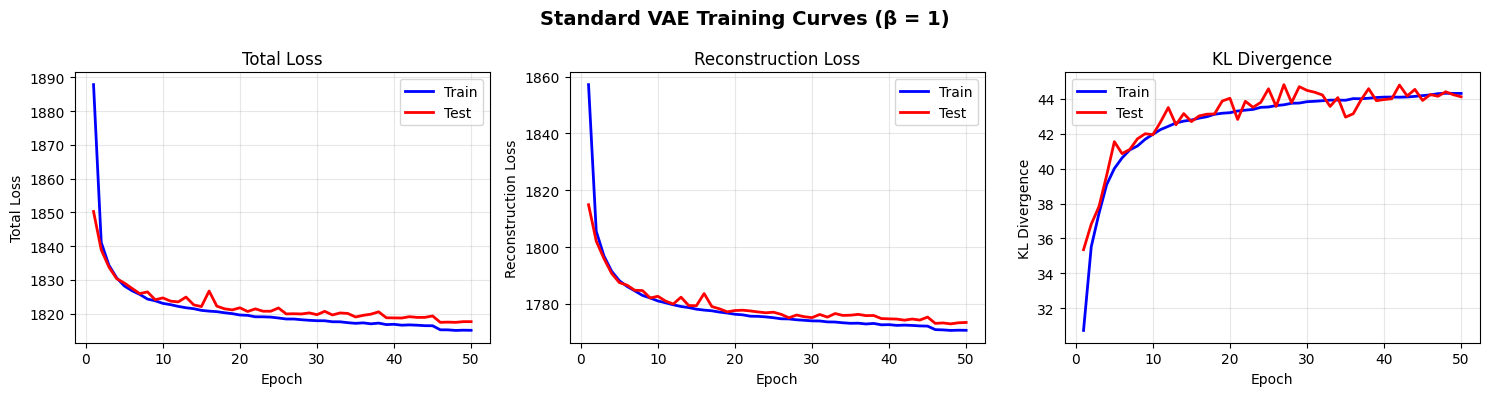

In [ ]:
# Plot training curves for β = 1
plot_training_curves(history_beta1, title="Standard VAE Training Curves (β = 1)")

---
## 5. Generated Images from Random Noise

Generate a 4×4 grid of images "dreamed up" by the model from random latent vectors sampled from N(0, I).


GENERATED IMAGES FROM RANDOM NOISE (β = 1)



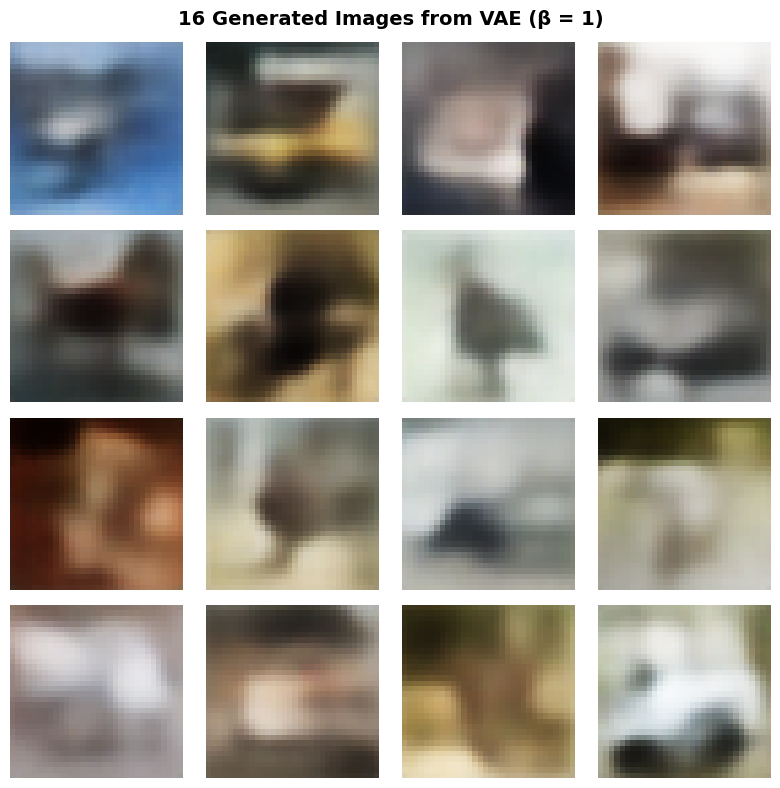

In [ ]:
def show_generated_images(model, num_images=16, title="Generated Images"):
    """
    Generate and display images from random latent vectors.
    """
    model.eval()

    # Generate images
    generated = model.generate(num_images)
    generated = generated.cpu()

    # Create grid
    grid_size = int(np.sqrt(num_images))
    fig, axes = plt.subplots(grid_size, grid_size, figsize=(8, 8))

    for idx, ax in enumerate(axes.flatten()):
        if idx < num_images:
            img = generated[idx].permute(1, 2, 0).numpy()
            img = np.clip(img, 0, 1)
            ax.imshow(img)
        ax.axis('off')

    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Generate images from the trained VAE
print("\n" + "="*60)
print("GENERATED IMAGES FROM RANDOM NOISE (β = 1)")
print("="*60 + "\n")

show_generated_images(vae_beta1, num_images=16, title="16 Generated Images from VAE (β = 1)")

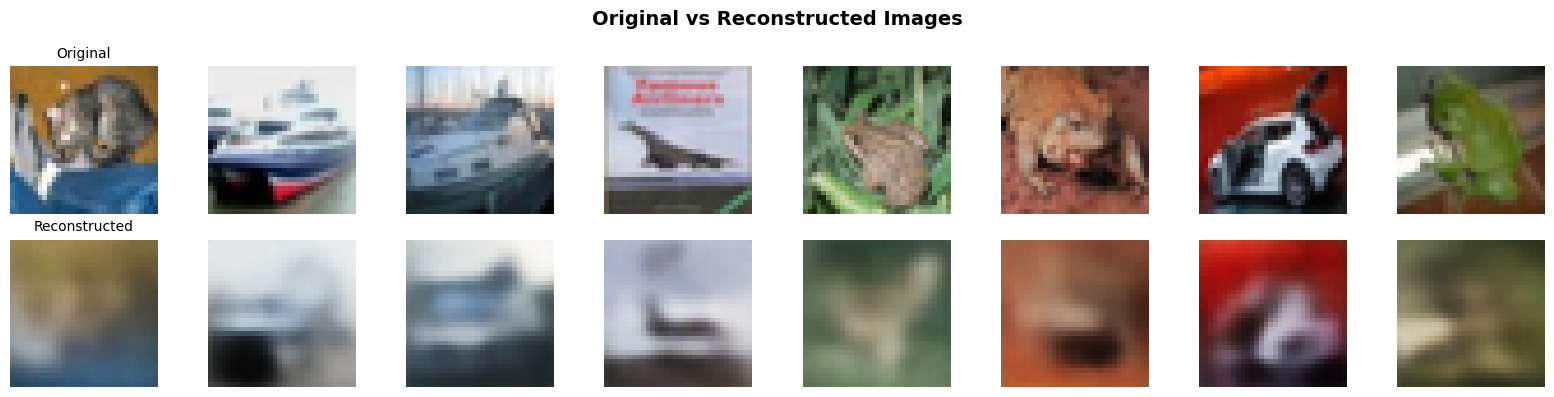

In [ ]:
def show_reconstructions(model, data_loader, num_images=8):
    """
    Show original images alongside their reconstructions.
    """
    model.eval()

    # Get a batch of images
    data, labels = next(iter(data_loader))
    data = data[:num_images].to(device)

    # Reconstruct
    with torch.no_grad():
        recon, _, _, _ = model(data)

    # Plot
    fig, axes = plt.subplots(2, num_images, figsize=(16, 4))

    for i in range(num_images):
        # Original
        orig = data[i].cpu().permute(1, 2, 0).numpy()
        axes[0, i].imshow(np.clip(orig, 0, 1))
        axes[0, i].axis('off')
        if i == 0:
            axes[0, i].set_title('Original', fontsize=10)

        # Reconstruction
        rec = recon[i].cpu().permute(1, 2, 0).numpy()
        axes[1, i].imshow(np.clip(rec, 0, 1))
        axes[1, i].axis('off')
        if i == 0:
            axes[1, i].set_title('Reconstructed', fontsize=10)

    plt.suptitle('Original vs Reconstructed Images', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Show reconstructions
show_reconstructions(vae_beta1, test_loader, num_images=8)

---
## 6. Task 3: Latent Space Interpolation

Test the model's "imagination" by blending two distinct images together through linear interpolation in latent space.


TASK 3: LATENT SPACE INTERPOLATION



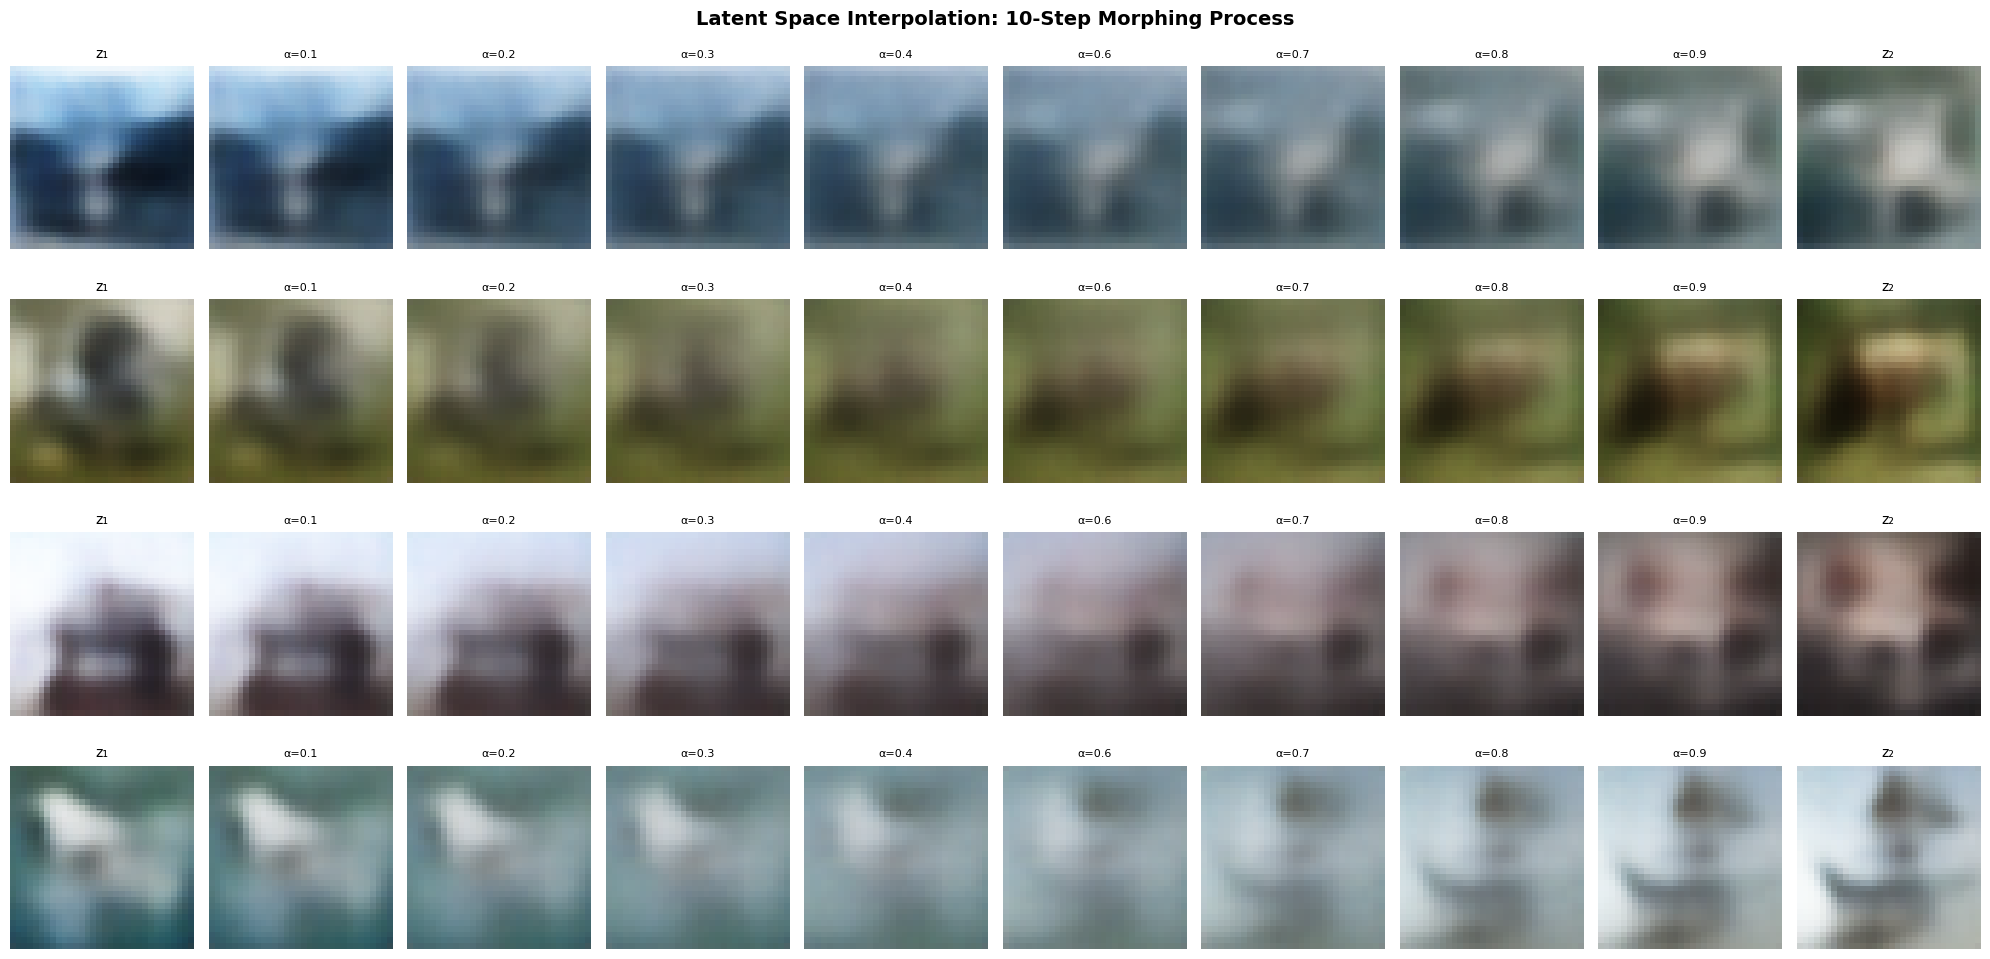

In [ ]:
def latent_space_interpolation(model, num_steps=10, num_rows=3):
    """
    Perform latent space interpolation between random points.

    For each row:
    1. Sample two random latent vectors z1 and z2
    2. Create a linear interpolation path between them
    3. Decode each point along the path

    Parameters:
    - model: Trained VAE model
    - num_steps: Number of interpolation steps
    - num_rows: Number of interpolation sequences to show
    """
    model.eval()

    fig, axes = plt.subplots(num_rows, num_steps, figsize=(20, num_rows * 2.5))

    with torch.no_grad():
        for row in range(num_rows):
            # Sample two random latent vectors
            z1 = torch.randn(1, model.latent_dim).to(device)
            z2 = torch.randn(1, model.latent_dim).to(device)

            # Linear interpolation
            alphas = np.linspace(0, 1, num_steps)

            for col, alpha in enumerate(alphas):
                # Interpolated latent vector
                z_interp = (1 - alpha) * z1 + alpha * z2

                # Decode
                img = model.decoder(z_interp)
                img = img[0].cpu().permute(1, 2, 0).numpy()
                img = np.clip(img, 0, 1)

                # Plot
                ax = axes[row, col] if num_rows > 1 else axes[col]
                ax.imshow(img)
                ax.axis('off')

                # Labels for first and last
                if col == 0:
                    ax.set_title(f'z₁', fontsize=10)
                elif col == num_steps - 1:
                    ax.set_title(f'z₂', fontsize=10)
                else:
                    ax.set_title(f'α={alpha:.1f}', fontsize=8)

    plt.suptitle('Latent Space Interpolation: 10-Step Morphing Process',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

print("\n" + "="*60)
print("TASK 3: LATENT SPACE INTERPOLATION")
print("="*60 + "\n")

latent_space_interpolation(vae_beta1, num_steps=10, num_rows=4)

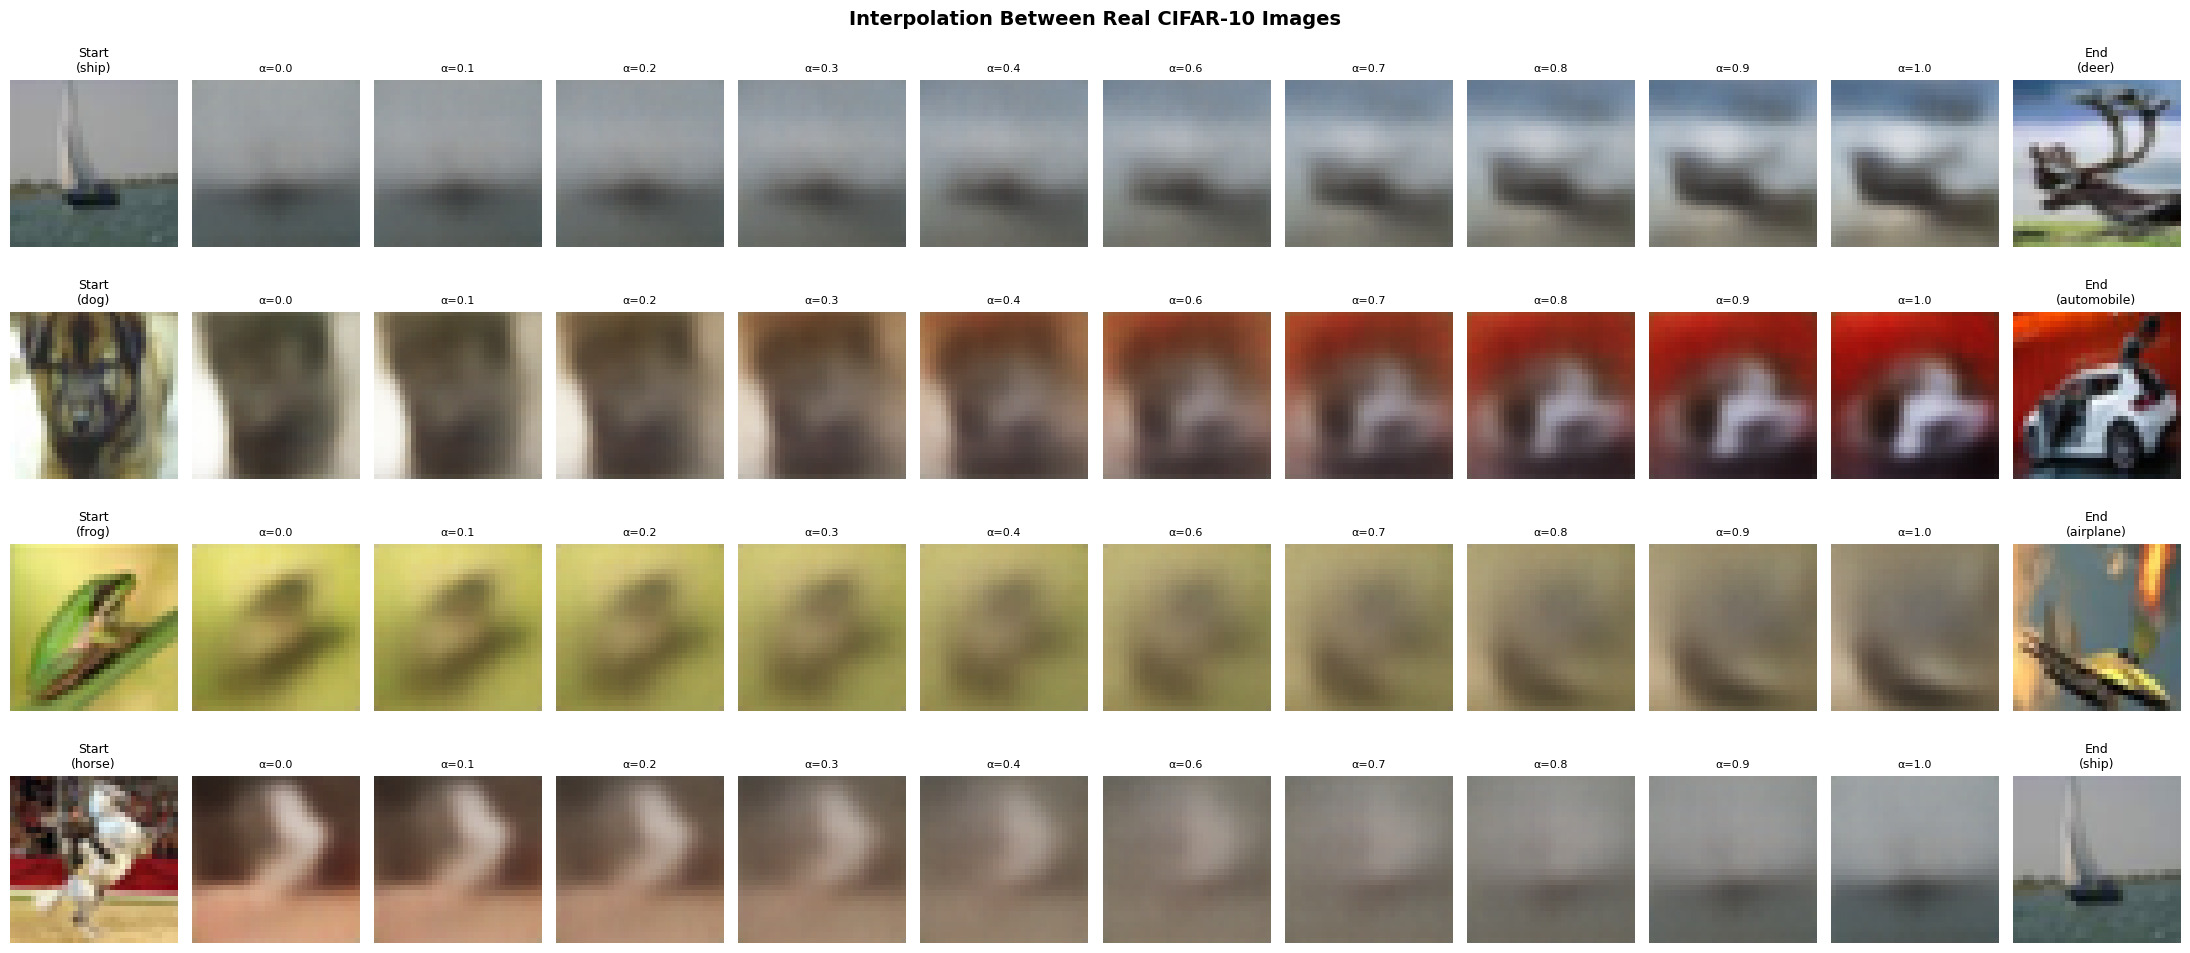

In [ ]:
def interpolate_real_images(model, data_loader, num_steps=10, num_pairs=3):
    """
    Interpolate between real images from the dataset.

    1. Encode two real images to their latent representations
    2. Interpolate in latent space
    3. Decode the interpolated points
    """
    model.eval()

    # Get images from different classes
    data, labels = next(iter(data_loader))

    fig, axes = plt.subplots(num_pairs, num_steps + 2, figsize=(22, num_pairs * 2.5))

    with torch.no_grad():
        for row in range(num_pairs):
            # Select two random images from the batch
            idx1, idx2 = np.random.choice(len(data), 2, replace=False)
            img1, img2 = data[idx1:idx1+1].to(device), data[idx2:idx2+1].to(device)
            label1, label2 = CLASSES[labels[idx1]], CLASSES[labels[idx2]]

            # Encode both images
            mu1, _ = model.encoder(img1)
            mu2, _ = model.encoder(img2)

            # Show original image 1
            ax = axes[row, 0] if num_pairs > 1 else axes[0]
            orig1 = img1[0].cpu().permute(1, 2, 0).numpy()
            ax.imshow(np.clip(orig1, 0, 1))
            ax.axis('off')
            ax.set_title(f'Start\n({label1})', fontsize=9)

            # Interpolation
            alphas = np.linspace(0, 1, num_steps)
            for col, alpha in enumerate(alphas):
                z_interp = (1 - alpha) * mu1 + alpha * mu2
                img_interp = model.decoder(z_interp)
                img_interp = img_interp[0].cpu().permute(1, 2, 0).numpy()

                ax = axes[row, col + 1] if num_pairs > 1 else axes[col + 1]
                ax.imshow(np.clip(img_interp, 0, 1))
                ax.axis('off')
                ax.set_title(f'α={alpha:.1f}', fontsize=8)

            # Show original image 2
            ax = axes[row, -1] if num_pairs > 1 else axes[-1]
            orig2 = img2[0].cpu().permute(1, 2, 0).numpy()
            ax.imshow(np.clip(orig2, 0, 1))
            ax.axis('off')
            ax.set_title(f'End\n({label2})', fontsize=9)

    plt.suptitle('Interpolation Between Real CIFAR-10 Images',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Interpolate between real images
interpolate_real_images(vae_beta1, test_loader, num_steps=10, num_pairs=4)

---
## 7. Task 4: β-VAE Modification

The β-VAE introduces a hyperparameter β that weighs the KL divergence term:

$$\mathcal{L} = \mathcal{L}_{recon} + \beta \cdot \mathcal{L}_{KL}$$

- **β = 1**: Standard VAE
- **β > 1**: Encourages more disentangled representations but may sacrifice reconstruction quality
- **β < 1**: Better reconstruction but potentially more entangled latent space

In [ ]:
# Train β-VAE with β = 5
print("\n" + "="*60)
print("TRAINING β-VAE (β = 5)")
print("="*60 + "\n")

vae_beta5 = VAE(latent_dim=LATENT_DIM, beta=5.0).to(device)

history_beta5 = train_vae(
    vae_beta5,
    train_loader,
    test_loader,
    epochs=EPOCHS,
    lr=LEARNING_RATE,
    beta=5.0
)


TRAINING β-VAE (β = 5)

Training VAE with β = 5.0


Epoch 1/50: 100%|██████████| 391/391 [00:09<00:00, 40.92it/s, loss=1943.28, recon=1890.65, kl=10.53]


Epoch 1: Train Loss=1966.83 | Test Loss=1931.89 | LR=0.001000


Epoch 2/50: 100%|██████████| 391/391 [00:09<00:00, 40.60it/s, loss=1930.60, recon=1874.56, kl=11.21]


Epoch 2: Train Loss=1925.99 | Test Loss=1923.39 | LR=0.001000


...

Epoch 48: Train Loss=1904.01 | Test Loss=1906.40 | LR=0.000250


Epoch 49/50: 100%|██████████| 391/391 [00:09<00:00, 43.36it/s, loss=1893.56, recon=1833.75, kl=11.96]


Epoch 49: Train Loss=1903.96 | Test Loss=1906.45 | LR=0.000250


Epoch 50/50: 100%|██████████| 391/391 [00:08<00:00, 43.45it/s, loss=1886.34, recon=1827.92, kl=11.68]


Epoch 50: Train Loss=1903.93 | Test Loss=1906.47 | LR=0.000250


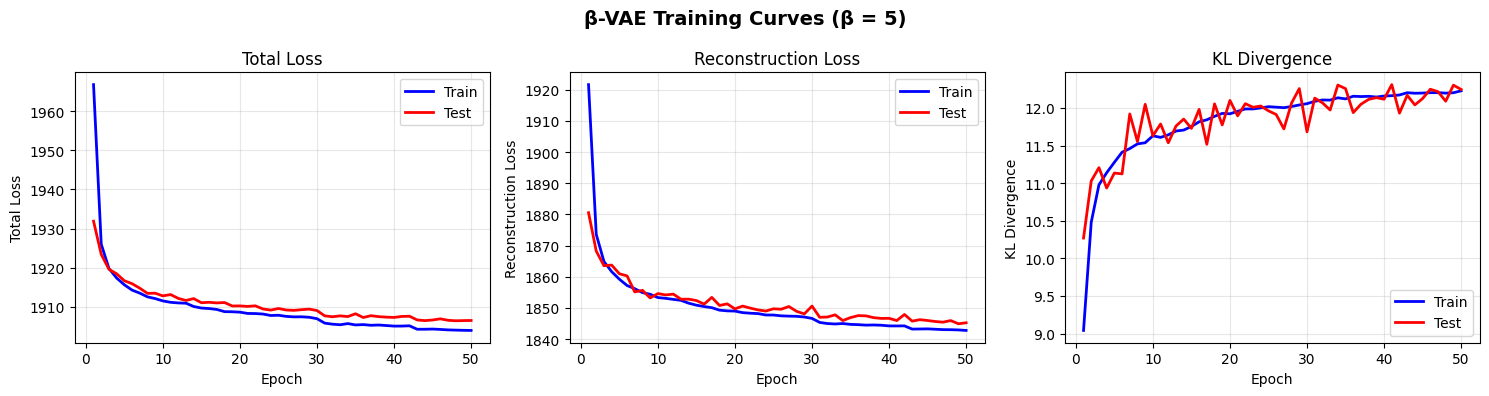

In [ ]:
# Plot training curves for β = 5
plot_training_curves(history_beta5, title="β-VAE Training Curves (β = 5)")

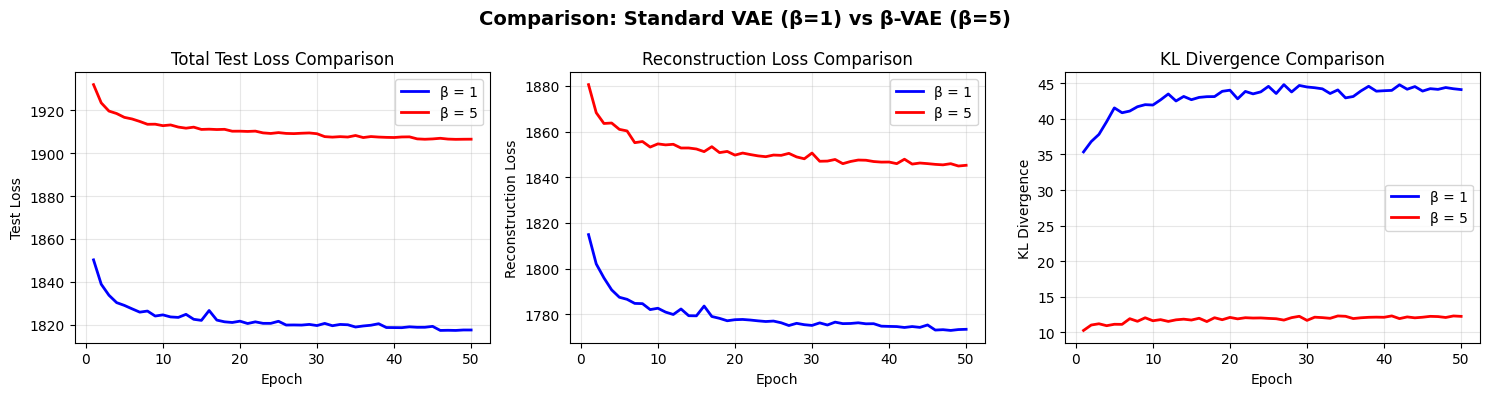

In [ ]:
def compare_beta_values(history1, history2, beta1=1, beta2=5):
    """
    Compare training metrics between two β values.
    """
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    epochs = range(1, len(history1['train_loss']) + 1)

    # Total Loss Comparison
    axes[0].plot(epochs, history1['test_loss'], 'b-', label=f'β = {beta1}', linewidth=2)
    axes[0].plot(epochs, history2['test_loss'], 'r-', label=f'β = {beta2}', linewidth=2)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Test Loss')
    axes[0].set_title('Total Test Loss Comparison')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Reconstruction Loss Comparison
    axes[1].plot(epochs, history1['test_recon'], 'b-', label=f'β = {beta1}', linewidth=2)
    axes[1].plot(epochs, history2['test_recon'], 'r-', label=f'β = {beta2}', linewidth=2)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Reconstruction Loss')
    axes[1].set_title('Reconstruction Loss Comparison')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # KL Divergence Comparison
    axes[2].plot(epochs, history1['test_kl'], 'b-', label=f'β = {beta1}', linewidth=2)
    axes[2].plot(epochs, history2['test_kl'], 'r-', label=f'β = {beta2}', linewidth=2)
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('KL Divergence')
    axes[2].set_title('KL Divergence Comparison')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.suptitle(f'Comparison: Standard VAE (β={beta1}) vs β-VAE (β={beta2})',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Compare the two models
compare_beta_values(history_beta1, history_beta5, beta1=1, beta2=5)


GENERATED IMAGES COMPARISON



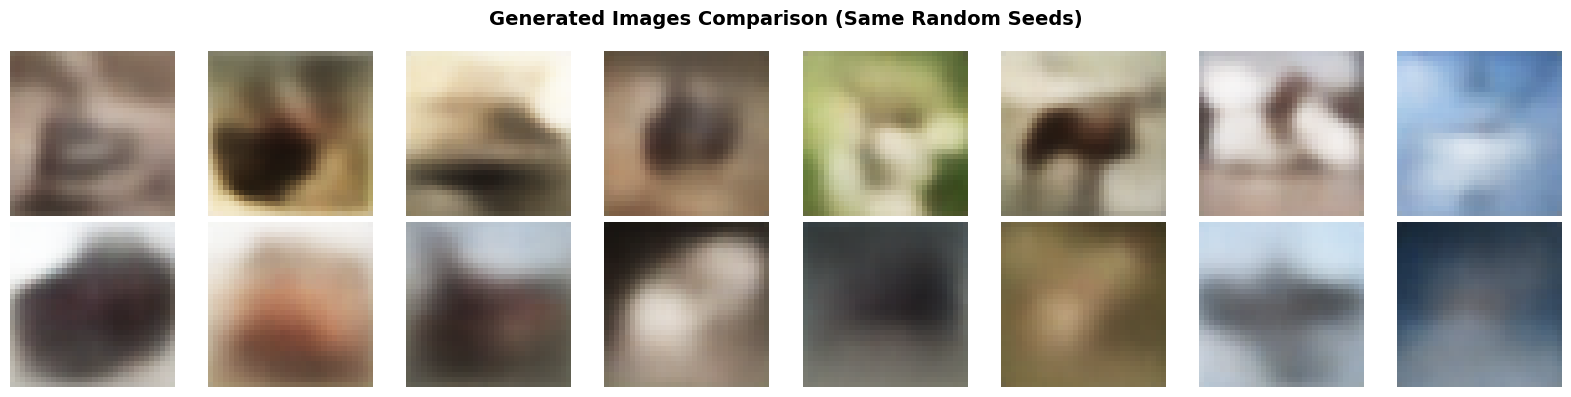

In [ ]:
def compare_generated_images(model1, model2, beta1=1, beta2=5, num_images=8):
    """
    Compare generated images from two models with different β values.
    """
    model1.eval()
    model2.eval()

    # Use the same random seed for fair comparison
    torch.manual_seed(42)
    z = torch.randn(num_images, model1.latent_dim).to(device)

    with torch.no_grad():
        gen1 = model1.decoder(z).cpu()
        gen2 = model2.decoder(z).cpu()

    fig, axes = plt.subplots(2, num_images, figsize=(16, 4))

    for i in range(num_images):
        # β = 1
        img1 = gen1[i].permute(1, 2, 0).numpy()
        axes[0, i].imshow(np.clip(img1, 0, 1))
        axes[0, i].axis('off')
        if i == 0:
            axes[0, i].set_ylabel(f'β = {beta1}', fontsize=12)

        # β = 5
        img2 = gen2[i].permute(1, 2, 0).numpy()
        axes[1, i].imshow(np.clip(img2, 0, 1))
        axes[1, i].axis('off')
        if i == 0:
            axes[1, i].set_ylabel(f'β = {beta2}', fontsize=12)

    plt.suptitle('Generated Images Comparison (Same Random Seeds)',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Compare generated images
print("\n" + "="*60)
print("GENERATED IMAGES COMPARISON")
print("="*60 + "\n")

compare_generated_images(vae_beta1, vae_beta5, beta1=1, beta2=5, num_images=8)

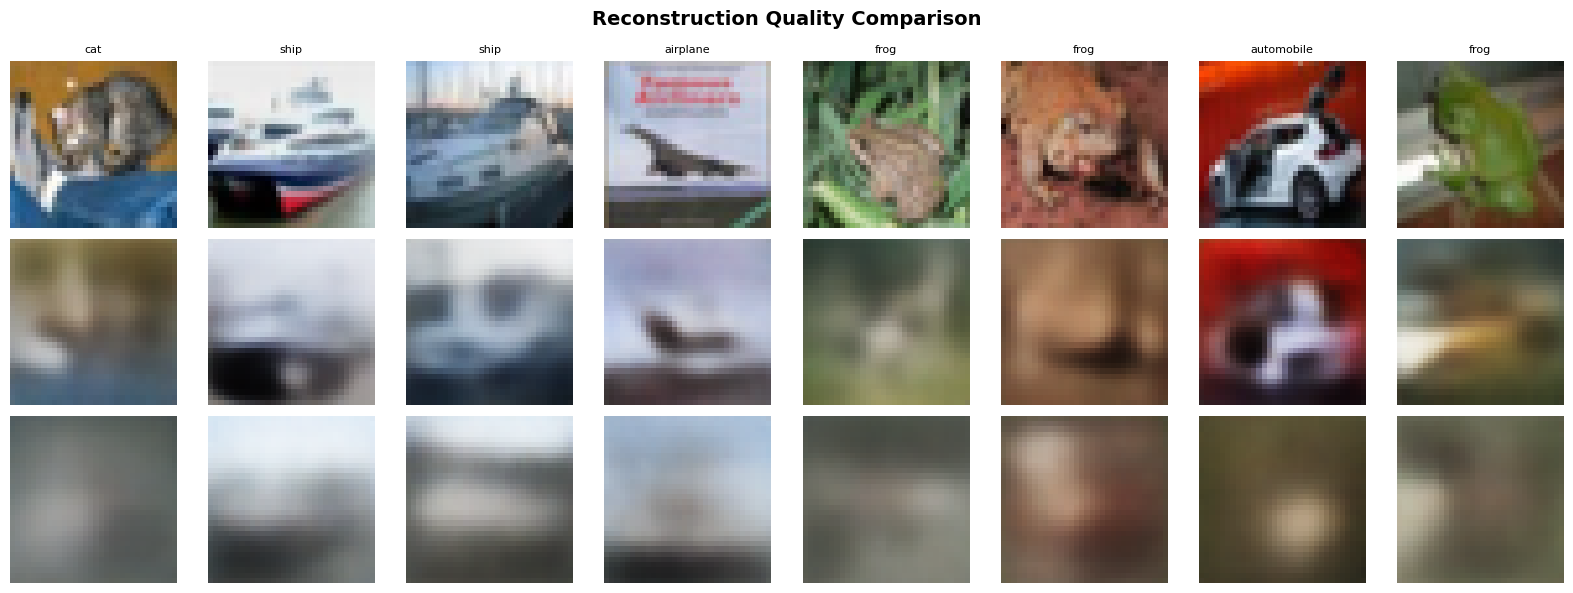

In [ ]:
def compare_reconstructions(model1, model2, data_loader, beta1=1, beta2=5, num_images=8):
    """
    Compare reconstruction quality between two models.
    """
    model1.eval()
    model2.eval()

    data, labels = next(iter(data_loader))
    data = data[:num_images].to(device)

    with torch.no_grad():
        recon1, _, _, _ = model1(data)
        recon2, _, _, _ = model2(data)

    fig, axes = plt.subplots(3, num_images, figsize=(16, 6))

    for i in range(num_images):
        # Original
        orig = data[i].cpu().permute(1, 2, 0).numpy()
        axes[0, i].imshow(np.clip(orig, 0, 1))
        axes[0, i].axis('off')
        axes[0, i].set_title(CLASSES[labels[i]], fontsize=8)
        if i == 0:
            axes[0, i].set_ylabel('Original', fontsize=10)

        # Reconstruction β = 1
        rec1 = recon1[i].cpu().permute(1, 2, 0).numpy()
        axes[1, i].imshow(np.clip(rec1, 0, 1))
        axes[1, i].axis('off')
        if i == 0:
            axes[1, i].set_ylabel(f'β = {beta1}', fontsize=10)

        # Reconstruction β = 5
        rec2 = recon2[i].cpu().permute(1, 2, 0).numpy()
        axes[2, i].imshow(np.clip(rec2, 0, 1))
        axes[2, i].axis('off')
        if i == 0:
            axes[2, i].set_ylabel(f'β = {beta2}', fontsize=10)

    plt.suptitle('Reconstruction Quality Comparison', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Compare reconstructions
compare_reconstructions(vae_beta1, vae_beta5, test_loader, beta1=1, beta2=5)


INTERPOLATION COMPARISON

Latent Space Interpolation with β = 1:


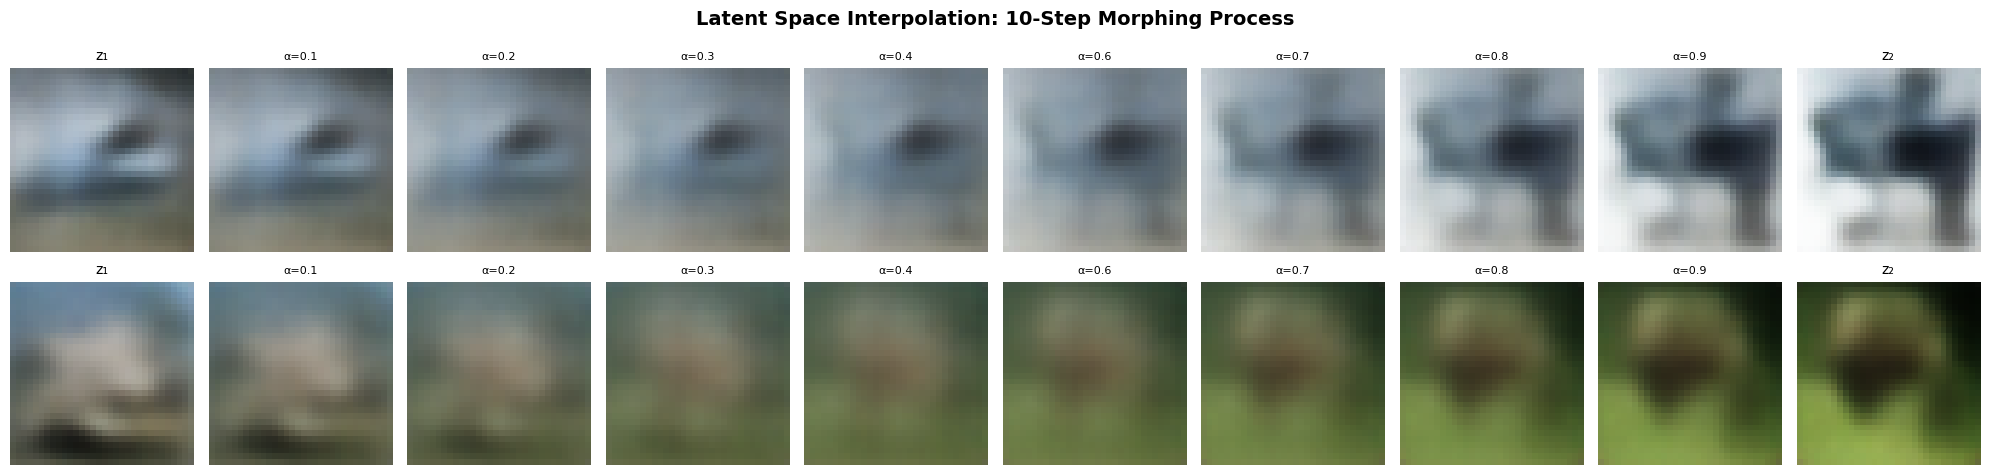


Latent Space Interpolation with β = 5:


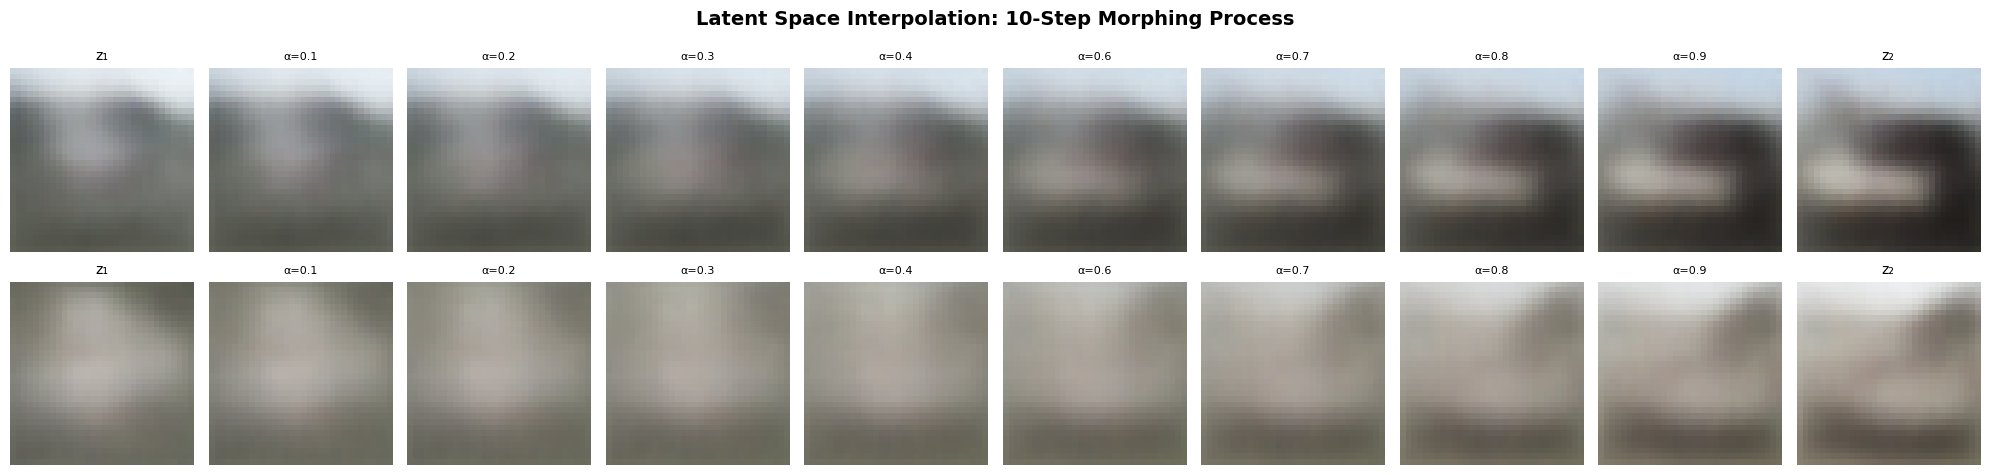

In [ ]:
# Interpolation comparison
print("\n" + "="*60)
print("INTERPOLATION COMPARISON")
print("="*60 + "\n")

print("Latent Space Interpolation with β = 1:")
latent_space_interpolation(vae_beta1, num_steps=10, num_rows=2)

print("\nLatent Space Interpolation with β = 5:")
latent_space_interpolation(vae_beta5, num_steps=10, num_rows=2)


GENERATED IMAGES FROM β-VAE (β = 5)



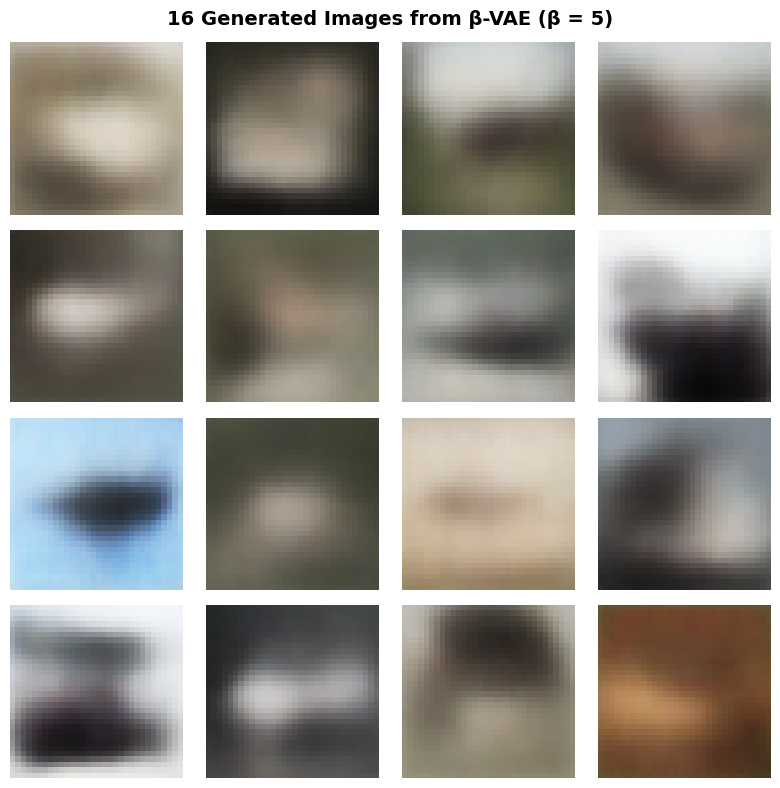

In [ ]:
# Generate 16 images grid for β = 5
print("\n" + "="*60)
print("GENERATED IMAGES FROM β-VAE (β = 5)")
print("="*60 + "\n")

show_generated_images(vae_beta5, num_images=16, title="16 Generated Images from β-VAE (β = 5)")

---
## 8. Summary and Analysis

### β-VAE Analysis (Max 300 words)

In [ ]:
# Print final metrics comparison
print("="*60)
print("FINAL METRICS COMPARISON")
print("="*60)
print(f"\nStandard VAE (β = 1):")
print(f"  Final Test Loss: {history_beta1['test_loss'][-1]:.2f}")
print(f"  Final Reconstruction Loss: {history_beta1['test_recon'][-1]:.2f}")
print(f"  Final KL Divergence: {history_beta1['test_kl'][-1]:.2f}")

print(f"\nβ-VAE (β = 5):")
print(f"  Final Test Loss: {history_beta5['test_loss'][-1]:.2f}")
print(f"  Final Reconstruction Loss: {history_beta5['test_recon'][-1]:.2f}")
print(f"  Final KL Divergence: {history_beta5['test_kl'][-1]:.2f}")

print(f"\nDifferences (β=5 vs β=1):")
recon_diff = history_beta5['test_recon'][-1] - history_beta1['test_recon'][-1]
kl_diff = history_beta5['test_kl'][-1] - history_beta1['test_kl'][-1]
print(f"  Reconstruction Loss Change: {recon_diff:+.2f} ({'worse' if recon_diff > 0 else 'better'})")
print(f"  KL Divergence Change: {kl_diff:+.2f} ({'higher' if kl_diff > 0 else 'lower'})")

FINAL METRICS COMPARISON

Standard VAE (β = 1):
  Final Test Loss: 1817.59
  Final Reconstruction Loss: 1773.48
  Final KL Divergence: 44.12

β-VAE (β = 5):
  Final Test Loss: 1906.47
  Final Reconstruction Loss: 1845.24
  Final KL Divergence: 12.25

Differences (β=5 vs β=1):
  Reconstruction Loss Change: +71.76 (worse)
  KL Divergence Change: -31.87 (lower)


### Written Summary: Impact of β on VAE Performance

**Observations and Analysis:**

The β-VAE modification introduces a trade-off between reconstruction quality and latent space organization. Our experiments comparing β=1 (standard VAE) with β=5 reveal several key insights:

**1. Reconstruction Quality:**
With β=1, the model produces sharper, more detailed reconstructions as it prioritizes minimizing reconstruction error. The higher β=5 setting results in blurrier, less detailed images because the model allocates more capacity to regularizing the latent space rather than precise reconstruction.

**2. Latent Space Organization:**
Higher β values encourage the latent space to conform more closely to a standard normal distribution, promoting disentanglement. This means individual latent dimensions are more likely to capture independent factors of variation (e.g., color, shape, orientation). The lower KL divergence in β=5 models indicates tighter clustering around the prior.

**3. Generation Quality:**
Interestingly, while reconstructions suffer with higher β, samples from random noise may appear more coherent since the latent space is better organized. The model generalizes better but loses fine-grained details.

**4. Interpolation Smoothness:**
Both models produce smooth interpolations, but β=5 transitions appear more semantically meaningful, transitioning between higher-level features rather than pixel-level blending.

**Conclusion:**
The choice of β depends on the application. For tasks requiring high-fidelity reconstruction, β=1 is preferable. For applications needing interpretable, disentangled representations (e.g., controlled image manipulation), higher β values offer advantages despite sacrificing reconstruction quality. This fundamental trade-off between reconstruction and regularization is central to understanding VAE behavior.

In [ ]:
# Save models (optional)
torch.save({
    'model_state_dict': vae_beta1.state_dict(),
    'history': history_beta1,
    'latent_dim': LATENT_DIM,
    'beta': 1.0
}, 'vae_beta1.pth')

torch.save({
    'model_state_dict': vae_beta5.state_dict(),
    'history': history_beta5,
    'latent_dim': LATENT_DIM,
    'beta': 5.0
}, 'vae_beta5.pth')

print("Models saved successfully!")

Models saved successfully!


---
## 9. Submission Checklist

✅ **Task 1: Architectural Design**
- [x] Encoder network (compresses images to μ and log σ²)
- [x] Decoder network (reconstructs images from latent vectors)
- [x] Reparameterization trick implementation

✅ **Task 2: Training and Performance**
- [x] Trained on CIFAR-10 dataset
- [x] Training curves showing improvement
- [x] Generated recognizable objects

✅ **Task 3: Latent Space Interpolation**
- [x] 10-step interpolation visualization
- [x] Smooth transitions between classes

✅ **Task 4: β-VAE Modification**
- [x] β = 1 (baseline) implementation
- [x] β = 5 (high regularization) implementation
- [x] Comparative analysis

✅ **Deliverables**
- [x] Full source code for Encoder, Decoder, Loss function
- [x] Training curves (graphs)
- [x] 16-image grid from random noise
- [x] 10-step interpolation visualization
- [x] Written summary on β impact (< 300 words)